# New Section

In [ ]:
# BASIC LIBRARIES
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESSING
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# FEATURE SELECTION
from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_classif,
    SelectKBest,
    f_classif,
    RFE
)

# MODELS
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

# METRICS
from sklearn.metrics import accuracy_score, matthews_corrcoef

# PERMUTATION IMPORTANCE
from sklearn.inspection import permutation_importance

# DIMENSIONALITY REDUCTION
from sklearn.decomposition import PCA

# SETTINGS
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/102_Nutrients_Data.csv')

In [ ]:
print(df.shape)

df.head()

(2970, 103)


,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",Calcium,Iron,Magnesium,Phosphorus,Potassium,Sodium,Zinc,Copper,Selenium,Retinol,"Vitamin A, RAE","Carotene, beta","Carotene, alpha",Vitamin E (alpha-tocopherol),Vitamin D (D2 + D3),"Cryptoxanthin, beta",Lycopene,Lutein + zeaxanthin,Vitamin C,Thiamin,Riboflavin,Niacin,Vitamin B-6,"Folate, total",Vitamin B-12,"Choline, total",Vitamin K (phylloquinone),Folic acid,"Folate, food","Folate, DFE","Vitamin E, added","Vitamin B-12, added",Cholesterol,"Fatty acids, total saturated",4:0,6:0,8:0,10:0,12:0,14:0,16:0,18:0,18:1,18:2,18:3,20:4,22:6 n-3,16:1,18:4,20:1,20:5 n-3,22:1,22:5 n-3,"Fatty acids, total monounsaturated","Fatty acids, total polyunsaturated",Daidzein,Genistein,Glycitein,Cyanidin,Petunidin,Delphinidin,Malvidin,Pelargonidin,Peonidin,(+)-Catechin,(-)-Epigallocatechin,(-)-Epicatechin,(-)-Epicatechin 3-gallate,(-)-Epigallocatechin 3-gallate,Theaflavin,Thearubigins,Eriodictyol,Hesperetin,Naringenin,Apigenin,Luteolin,Isorhamnetin,Kaempferol,Myricetin,Quercetin,"Theaflavin-3,3'-digallate",Theaflavin-3'-gallate,Theaflavin-3-gallate,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
0,1.03,4.38,6.89,70.0,0.0,87.50,0.0,0.0,6.89,0.0,32.0,0.03,3.0,14.0,51.0,17.0,0.17,0.052,1.8,60.0,61.0,7.0,0.0,0.08,0.1,0.0,0.0,0.0,5.0,0.014,0.036,0.177,0.011,5.0,0.05,16.0,0.3,0.0,5.0,5.0,0.0,0.0,14.0,2.009,0.000,0.000,0.000,0.063,0.256,0.321,0.919,0.293,1.475,0.374,0.052,0.026,0.0,0.129,0.0,0.040,0.0,0.0,0.0,1.658,0.497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,3.28,1.91,4.85,50.0,0.0,89.25,0.0,0.0,5.08,0.0,119.0,0.03,11.0,91.0,142.0,44.0,0.43,0.014,3.1,53.0,54.0,4.0,0.0,0.04,1.2,0.0,0.0,0.0,0.1,0.040,0.180,0.092,0.037,5.0,0.49,15.8,0.2,0.0,5.0,5.0,0.0,0.0,7.0,1.154,0.057,0.041,0.033,0.046,0.049,0.173,0.513,0.225,0.483,0.065,0.027,0.000,0.0,0.013,0.0,0.001,0.0,0.0,0.0,0.507,0.094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,3.15,3.25,4.80,61.0,0.0,88.13,0.0,0.0,5.05,0.0,113.0,0.03,10.0,84.0,132.0,43.0,0.37,0.025,3.7,45.0,46.0,7.0,0.0,0.07,1.3,0.0,0.0,0.0,0.0,0.046,0.169,0.089,0.036,5.0,0.45,14.3,0.3,0.0,5.0,5.0,0.0,0.0,10.0,1.865,0.075,0.075,0.075,0.075,0.077,0.297,0.829,0.365,0.812,0.120,0.075,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.812,0.195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,3.10,3.46,4.46,61.0,0.0,88.20,0.0,0.0,4.46,0.0,101.0,0.05,5.0,86.0,253.0,3.0,0.38,0.010,2.0,28.0,29.0,7.0,0.0,0.08,1.3,0.0,0.0,0.0,0.9,0.020,0.105,0.043,0.034,5.0,0.36,16.0,0.3,0.0,5.0,5.0,0.0,0.0,14.0,2.154,0.112,0.066,0.039,0.087,0.097,0.348,0.910,0.419,0.870,0.078,0.050,0.000,0.0,0.077,0.0,0.000,0.0,0.0,0.0,0.999,0.128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,3.14,3.24,4.79,61.0,0.0,87.87,0.0,0.0,5.04,0.0,412.0,0.03,10.0,84.0,132.0,43.0,0.37,0.025,3.7,45.0,46.0,7.0,0.0,0.07,1.3,0.0,0.0,0.0,0.0,0.046,0.168,0.089,0.036,5.0,0.45,14.3,0.3,0.0,5.0,5.0,0.0,0.0,10.0,1.859,0.075,0.075,0.075,0.075,0.077,0.296,0.827,0.364,0.810,0.120,0.075,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.810,0.194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
print(df.columns.tolist())

['Protein', 'Total Fat', 'Carbohydrate', 'Energy', 'Alcohol', 'Water', 'Caffeine', 'Theobromine', 'Sugars, total', 'Fiber, total dietary', 'Calcium', 'Iron', 'Magnesium', 'Phosphorus', 'Potassium', 'Sodium', 'Zinc', 'Copper', 'Selenium', 'Retinol', 'Vitamin A, RAE', 'Carotene, beta', 'Carotene, alpha', 'Vitamin E (alpha-tocopherol)', 'Vitamin D (D2 + D3)', 'Cryptoxanthin, beta', 'Lycopene', 'Lutein + zeaxanthin', 'Vitamin C', 'Thiamin', 'Riboflavin', 'Niacin', 'Vitamin B-6', 'Folate, total', 'Vitamin B-12', 'Choline, total', 'Vitamin K (phylloquinone)', 'Folic acid', 'Folate, food', 'Folate, DFE', 'Vitamin E, added', 'Vitamin B-12, added', 'Cholesterol', 'Fatty acids, total saturated', '4:0', '6:0', '8:0', '10:0', '12:0', '14:0', '16:0', '18:0', '18:1', '18:2', '18:3', '20:4', '22:6 n-3', '16:1', '18:4', '20:1', '20:5 n-3', '22:1', '22:5 n-3', 'Fatty acids, total monounsaturated', 'Fatty acids, total polyunsaturated', 'Daidzein', 'Genistein', 'Glycitein', 'Cyanidin', 'Petunidin', 'Delp

In [ ]:
df['Fiber, total dietary'].value_counts()

,count
"Fiber, total dietary",
0.0,844
1.6,73
0.1,69
1.1,68
0.2,67
...,...
26.9,1
19.0,1
18.0,1


In [ ]:
df.info() # check data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Columns: 103 entries, Protein to novaclass
dtypes: float64(102), int64(1)
memory usage: 2.3 MB


In [ ]:
# check missing values

missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
df.duplicated().sum()

np.int64(362)

In [ ]:
duplicates = df[df.duplicated()]

duplicates.head()

,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",Calcium,Iron,Magnesium,Phosphorus,Potassium,Sodium,Zinc,Copper,Selenium,Retinol,"Vitamin A, RAE","Carotene, beta","Carotene, alpha",Vitamin E (alpha-tocopherol),Vitamin D (D2 + D3),"Cryptoxanthin, beta",Lycopene,Lutein + zeaxanthin,Vitamin C,Thiamin,Riboflavin,Niacin,Vitamin B-6,"Folate, total",Vitamin B-12,"Choline, total",Vitamin K (phylloquinone),Folic acid,"Folate, food","Folate, DFE","Vitamin E, added","Vitamin B-12, added",Cholesterol,"Fatty acids, total saturated",4:0,6:0,8:0,10:0,12:0,14:0,16:0,18:0,18:1,18:2,18:3,20:4,22:6 n-3,16:1,18:4,20:1,20:5 n-3,22:1,22:5 n-3,"Fatty acids, total monounsaturated","Fatty acids, total polyunsaturated",Daidzein,Genistein,Glycitein,Cyanidin,Petunidin,Delphinidin,Malvidin,Pelargonidin,Peonidin,(+)-Catechin,(-)-Epigallocatechin,(-)-Epicatechin,(-)-Epicatechin 3-gallate,(-)-Epigallocatechin 3-gallate,Theaflavin,Thearubigins,Eriodictyol,Hesperetin,Naringenin,Apigenin,Luteolin,Isorhamnetin,Kaempferol,Myricetin,Quercetin,"Theaflavin-3,3'-digallate",Theaflavin-3'-gallate,Theaflavin-3-gallate,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
9,3.30,1.98,4.80,50.0,0.0,89.21,0.0,0.0,5.06,0.0,120.0,0.02,11.0,92.0,140.0,47.0,0.48,0.006,2.5,55.0,55.0,4.0,0.0,0.03,1.2,0.0,0.0,0.0,0.2,0.039,0.185,0.092,0.038,5.0,0.53,16.4,0.2,0.0,5.0,5.0,0.0,0.0,8.0,1.257,0.077,0.040,0.020,0.049,0.055,0.175,0.558,0.243,0.508,0.062,0.008,0.0,0.0,0.027,0.0,0.002,0.0,0.0,0.0,0.560,0.073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
10,3.37,0.97,4.99,42.0,0.0,89.92,0.0,0.0,5.20,0.0,125.0,0.03,11.0,95.0,150.0,44.0,0.42,0.010,3.3,58.0,58.0,2.0,0.0,0.01,1.2,0.0,0.0,0.0,0.0,0.020,0.185,0.093,0.037,5.0,0.47,17.7,0.1,0.0,5.0,5.0,0.0,0.0,5.0,0.633,0.024,0.018,0.013,0.027,0.029,0.091,0.287,0.126,0.250,0.030,0.004,0.0,0.0,0.017,0.0,0.000,0.0,0.0,0.0,0.277,0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13,3.33,3.40,4.74,63.0,0.0,87.73,0.0,0.0,4.74,0.0,128.0,0.05,13.0,97.0,139.0,57.0,0.36,0.010,2.0,2.0,2.0,0.0,0.0,0.13,0.0,0.0,0.0,0.0,0.9,0.030,0.123,0.087,0.040,5.0,0.34,15.0,0.8,0.0,5.0,5.0,0.0,0.0,2.0,3.101,0.000,0.000,0.173,0.130,2.047,0.399,0.191,0.148,0.100,0.008,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.100,0.010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
15,3.37,0.97,4.99,42.0,0.0,89.92,0.0,0.0,5.20,0.0,125.0,0.03,11.0,95.0,150.0,44.0,0.42,0.010,3.3,58.0,58.0,2.0,0.0,0.01,1.2,0.0,0.0,0.0,0.0,0.020,0.185,0.093,0.037,5.0,0.47,17.7,0.1,0.0,5.0,5.0,0.0,0.0,5.0,0.633,0.024,0.018,0.013,0.027,0.029,0.091,0.287,0.126,0.250,0.030,0.004,0.0,0.0,0.017,0.0,0.000,0.0,0.0,0.0,0.277,0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
16,3.37,0.97,4.99,42.0,0.0,89.83,0.0,0.0,5.20,0.0,225.0,0.03,11.0,95.0,150.0,44.0,0.42,0.010,3.3,58.0,58.0,2.0,0.0,0.01,1.2,0.0,0.0,0.0,0.0,0.020,0.185,0.093,0.037,5.0,0.47,17.7,0.1,0.0,5.0,5.0,0.0,0.0,5.0,0.632,0.024,0.018,0.013,0.027,0.029,0.091,0.287,0.126,0.250,0.030,0.004,0.0,0.0,0.017,0.0,0.000,0.0,0.0,0.0,0.277,0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
# remove duplicate values

df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(2608, 103)

In [ ]:
df[df["Protein"] == 3.37]

,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",Calcium,Iron,Magnesium,Phosphorus,Potassium,Sodium,Zinc,Copper,Selenium,Retinol,"Vitamin A, RAE","Carotene, beta","Carotene, alpha",Vitamin E (alpha-tocopherol),Vitamin D (D2 + D3),"Cryptoxanthin, beta",Lycopene,Lutein + zeaxanthin,Vitamin C,Thiamin,Riboflavin,Niacin,Vitamin B-6,"Folate, total",Vitamin B-12,"Choline, total",Vitamin K (phylloquinone),Folic acid,"Folate, food","Folate, DFE","Vitamin E, added","Vitamin B-12, added",Cholesterol,"Fatty acids, total saturated",4:0,6:0,8:0,10:0,12:0,14:0,16:0,18:0,18:1,18:2,18:3,20:4,22:6 n-3,16:1,18:4,20:1,20:5 n-3,22:1,22:5 n-3,"Fatty acids, total monounsaturated","Fatty acids, total polyunsaturated",Daidzein,Genistein,Glycitein,Cyanidin,Petunidin,Delphinidin,Malvidin,Pelargonidin,Peonidin,(+)-Catechin,(-)-Epigallocatechin,(-)-Epicatechin,(-)-Epicatechin 3-gallate,(-)-Epigallocatechin 3-gallate,Theaflavin,Thearubigins,Eriodictyol,Hesperetin,Naringenin,Apigenin,Luteolin,Isorhamnetin,Kaempferol,Myricetin,Quercetin,"Theaflavin-3,3'-digallate",Theaflavin-3'-gallate,Theaflavin-3-gallate,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
5,3.37,0.97,4.99,42.0,0.0,89.83,0.0,0.0,5.20,0.0,225.0,0.03,11.0,95.0,150.0,44.0,0.42,0.010,3.3,58.0,58.0,2.0,0.0,0.01,1.2,0.0,0.0,0.0,0.0,0.020,0.185,0.093,0.037,5.0,0.47,17.7,0.1,0.0,5.0,5.0,0.0,0.0,5.0,0.632,0.024,0.018,0.013,0.027,0.029,0.091,0.287,0.126,0.250,0.030,0.004,0.000,0.0,0.017,0.000,0.000,0.0,0.0,0.000,0.277,0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
8,3.37,0.97,4.99,42.0,0.0,89.92,0.0,0.0,5.20,0.0,125.0,0.03,11.0,95.0,150.0,44.0,0.42,0.010,3.3,58.0,58.0,2.0,0.0,0.01,1.2,0.0,0.0,0.0,0.0,0.020,0.185,0.093,0.037,5.0,0.47,17.7,0.1,0.0,5.0,5.0,0.0,0.0,5.0,0.633,0.024,0.018,0.013,0.027,0.029,0.091,0.287,0.126,0.250,0.030,0.004,0.000,0.0,0.017,0.000,0.000,0.0,0.0,0.000,0.277,0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
11,3.37,0.08,4.96,34.0,0.0,90.84,0.0,0.0,5.09,0.0,122.0,0.03,11.0,101.0,156.0,42.0,0.42,0.013,3.1,61.0,61.0,0.0,0.0,0.01,1.2,0.0,0.0,0.0,0.0,0.045,0.182,0.094,0.037,5.0,0.50,15.6,0.0,0.0,5.0,5.0,0.0,0.0,2.0,0.056,0.004,0.000,0.001,0.002,0.001,0.008,0.025,0.009,0.018,0.002,0.001,0.000,0.0,0.003,0.000,0.000,0.0,0.0,0.000,0.022,0.003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
100,3.37,6.52,19.59,148.0,0.0,69.65,0.0,0.0,13.63,0.9,115.0,0.46,13.0,98.0,166.0,81.0,0.57,0.103,3.2,91.0,91.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.026,0.660,0.213,0.060,0.0,0.22,27.3,0.4,0.0,0.0,0.0,0.0,0.0,23.0,3.962,0.198,0.152,0.066,0.154,0.174,0.593,1.724,0.795,1.607,0.261,0.029,0.007,0.0,0.116,0.012,0.004,0.0,0.0,0.003,1.785,0.316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


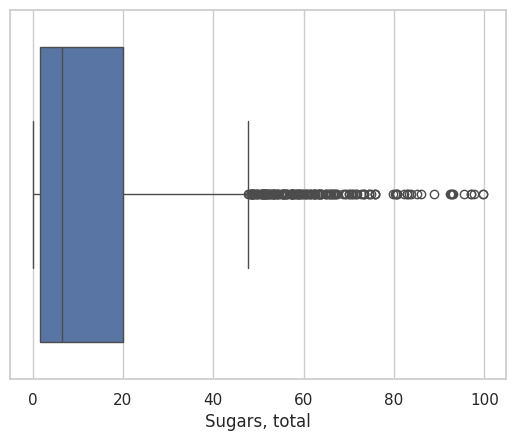

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Sugars, total"])
plt.show()

In [ ]:
Q1 = df["Sugars, total"].quantile(0.25)
Q3 = df["Sugars, total"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Sugars, total"] >= lower) & (df["Sugars, total"] <= upper)]

In [ ]:
df.shape

(2439, 103)

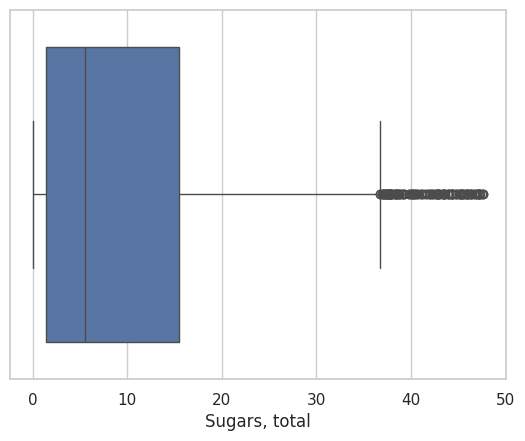

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Sugars, total"])
plt.show()

In [ ]:
df.sort_values(by="Sugars, total", ascending=False).head(20)

,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",Calcium,Iron,Magnesium,Phosphorus,Potassium,Sodium,Zinc,Copper,Selenium,Retinol,"Vitamin A, RAE","Carotene, beta","Carotene, alpha",Vitamin E (alpha-tocopherol),Vitamin D (D2 + D3),"Cryptoxanthin, beta",Lycopene,Lutein + zeaxanthin,Vitamin C,Thiamin,Riboflavin,Niacin,Vitamin B-6,"Folate, total",Vitamin B-12,"Choline, total",Vitamin K (phylloquinone),Folic acid,"Folate, food","Folate, DFE","Vitamin E, added","Vitamin B-12, added",Cholesterol,"Fatty acids, total saturated",4:0,6:0,8:0,10:0,12:0,14:0,16:0,18:0,18:1,18:2,18:3,20:4,22:6 n-3,16:1,18:4,20:1,20:5 n-3,22:1,22:5 n-3,"Fatty acids, total monounsaturated","Fatty acids, total polyunsaturated",Daidzein,Genistein,Glycitein,Cyanidin,Petunidin,Delphinidin,Malvidin,Pelargonidin,Peonidin,(+)-Catechin,(-)-Epigallocatechin,(-)-Epicatechin,(-)-Epicatechin 3-gallate,(-)-Epigallocatechin 3-gallate,Theaflavin,Thearubigins,Eriodictyol,Hesperetin,Naringenin,Apigenin,Luteolin,Isorhamnetin,Kaempferol,Myricetin,Quercetin,"Theaflavin-3,3'-digallate",Theaflavin-3'-gallate,Theaflavin-3-gallate,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
1938,2.19,0.43,64.81,244.0,0.0,30.41,0.0,0.0,47.66,7.4,40.0,1.52,34.0,63.0,746.0,17.0,0.39,0.293,0.8,0.0,56.0,630.0,28.0,1.17,0.0,46.0,0.0,84.0,2.1,0.030,0.153,1.804,0.161,4.0,0.00,13.9,33.9,0.0,4.0,4.0,0.0,0.00,0.0,0.060,0.000,0.000,0.004,0.002,0.001,0.000,0.029,0.024,0.043,0.070,0.011,0.000,0.000,0.020,0.0,0.000,0.000,0.0,0.0,0.063,0.082,0.0,0.0,0.0,2.86,0.0,0.02,0.0,0.00,0.02,4.82,0.59,12.67,0.02,0.25,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.20,0.74,0.01,5.96,0.0,0.0,0.0,0.0,28.16,2.90,18.35,18.35,0.00,0.00,6.91,0.0,3
1319,4.10,13.60,68.00,401.0,0.0,13.10,0.0,0.0,47.56,1.2,46.0,2.29,21.0,83.0,140.0,338.0,0.32,0.413,2.8,8.0,8.0,1.0,0.0,2.22,0.0,1.0,0.0,37.0,0.4,0.216,0.206,1.967,0.052,32.0,0.03,14.7,3.9,23.0,9.0,48.0,0.0,0.00,2.0,3.460,0.000,0.000,0.000,0.000,0.000,0.067,1.795,1.594,7.642,1.660,0.092,0.002,0.001,0.006,0.0,0.000,0.001,0.0,0.0,7.649,1.756,0.0,0.0,0.0,0.01,0.0,0.00,0.0,0.00,0.00,0.09,0.00,0.02,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.0,0.0,0.0,0.0,0.17,0.01,0.11,0.11,0.00,0.00,0.05,0.0,4
1711,6.76,1.93,87.99,391.0,0.0,2.22,0.0,0.0,47.47,3.4,10.0,1.90,57.0,141.0,148.0,236.0,1.24,0.230,6.5,0.0,0.0,0.0,0.0,1.04,0.0,0.0,0.0,0.0,0.0,0.140,0.110,4.300,0.050,19.0,0.15,14.5,1.3,0.0,19.0,19.0,0.0,0.00,0.0,0.360,0.000,0.000,0.010,0.000,0.000,0.003,0.271,0.068,0.421,0.869,0.058,0.001,0.000,0.008,0.0,0.000,0.000,0.0,0.0,0.430,0.930,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,4
1685,5.79,5.02,84.27,396.0,0.0,2.10,0.0,0.0,47.27,4.2,87.0,15.00,56.0,195.0,139.0,640.0,12.50,0.210,19.8,1001.0,1001.0,0.0,0.0,0.47,0.0,0.0,0.0,0.0,40.0,1.250,1.410,16.670,1.660,333.0,0.00,11.0,1.7,314.0,19.0,553.0,0.0,0.00,0.0,1.250,0.000,0.000,0.000,0.000,0.010,0.015,0.831,0.271,2.211,1.120,0.065,0.000,0.000,0.003,0.0,0.000,0.000,0.0,0.0,2.500,1.250,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,4
2673,10.22,33.21,54.34,538.0,0.0,0.45,18.0,198.0,47.22,3.8,110.0,1.39,47.0,163.0,394.0,41.0,0.93,0.170,0.0,35.0,35.0,0.0,0.0,3.17,0.0,0.0,0.0,5.0,0.9,0.140,0.140,3.440,0.070,38.0,0.33,47.4,3.6,0.0,38.0,38.0,0.0,0.00,10.0,14.130,0.339,0.123,0.070,0.133,0.146,0.461,6.730,5.700,7.991,4.365,0.001,0.000,0.000,0.052,0.0,0.127,0.000,0.0,0.0,8.203,4.366,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,2.20,0.00,5.76,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.77,0.0,0.0,0.0,0.0,8.73,0.00,7.96,7.96,0.00,0.00,0.77,0.0,4
1302,6.76,5.74,78.91,384.0,0.0,7.95,0.0,0.0,

In [ ]:
df["novaclass"].value_counts()

,count
novaclass,
4,1711
3,405
1,283
2,40


In [ ]:
core_features = [

    # macros
    'Protein',
    'Total Fat',
    'Carbohydrate',
    'Energy',
    'Water',

    # important sugars/fiber
    'Sugars, total',
    'Fiber, total dietary',

    # minerals
    'Sodium',
    'Potassium',
    'Calcium',
    'Iron',
    'Magnesium',
    'Zinc',

    # vitamins
    'Vitamin C',
    'Vitamin B-12',
    'Vitamin D (D2 + D3)',
    'Vitamin E (alpha-tocopherol)',

    # fat summaries
    'Fatty acids, total saturated',
    'Fatty acids, total monounsaturated',
    'Fatty acids, total polyunsaturated',

    # antioxidant summaries
    'Total flavonoids',
    'Total anthocyanidins',

    # target
    'novaclass'
]

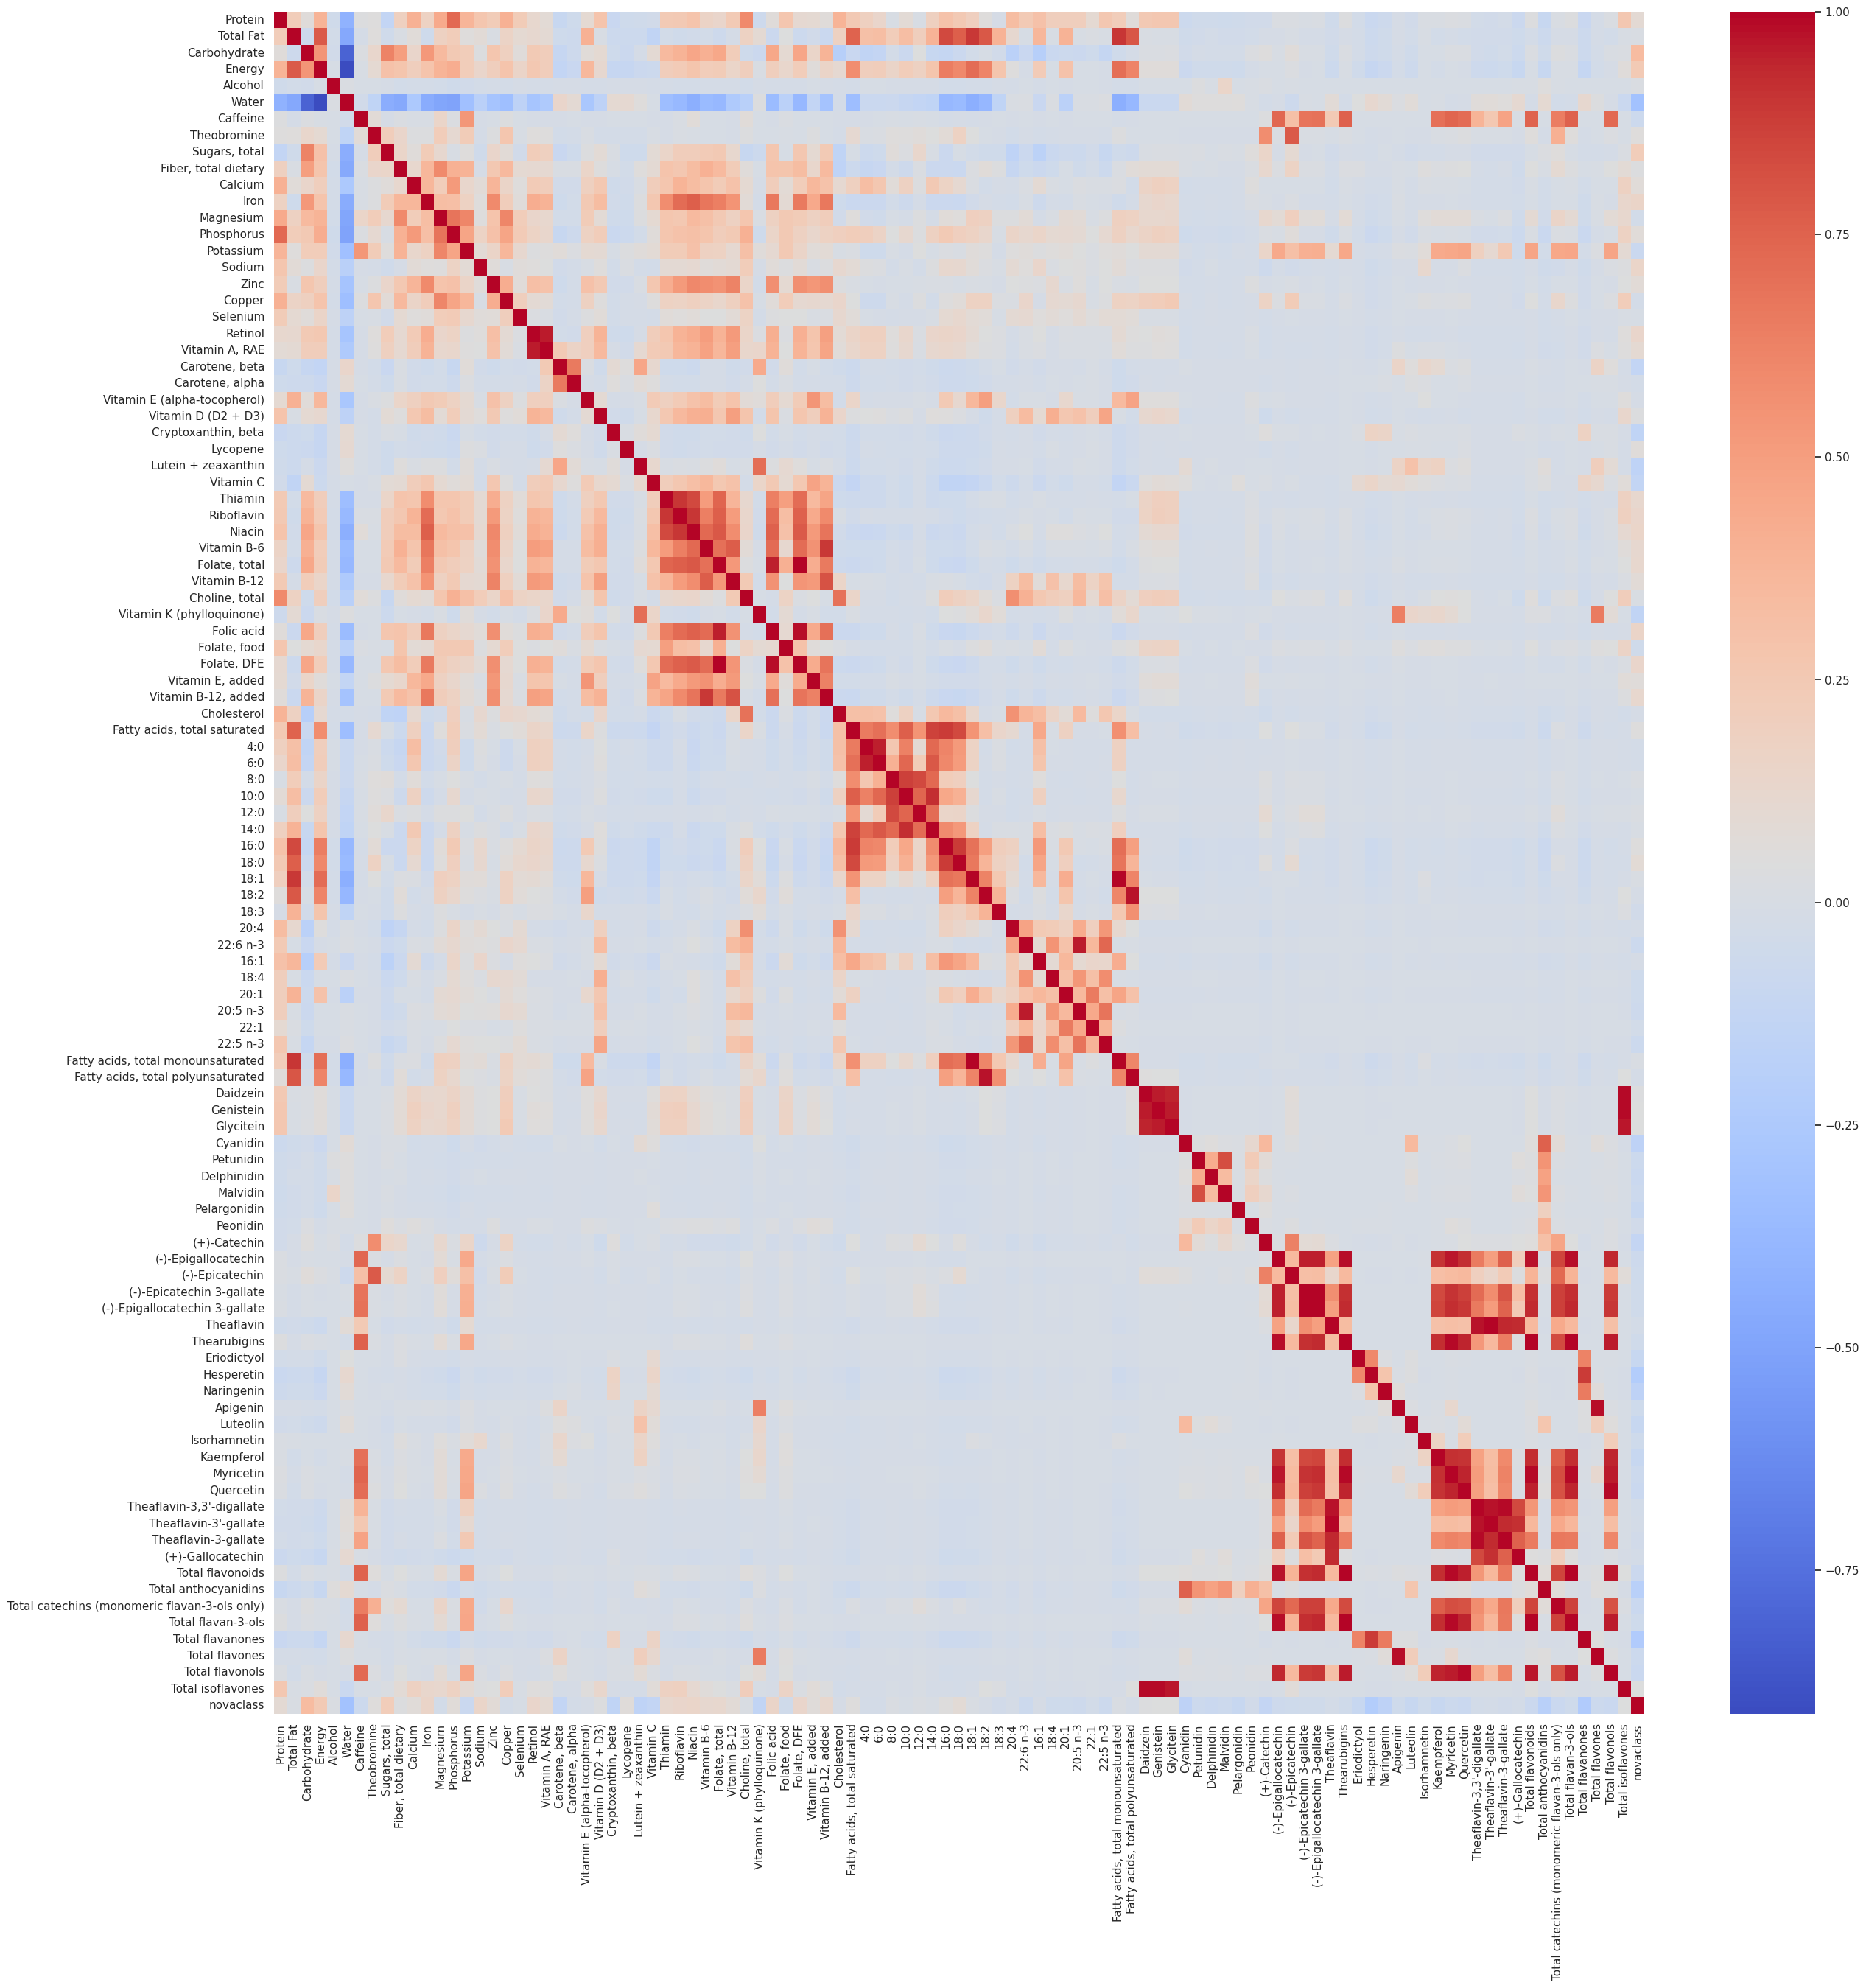

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 30))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [ ]:
X = df.drop("novaclass", axis=1)
corr_matrix = X.corr().abs()

In [ ]:

import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# ------------------------------------------
# PREPROCESSING X FOR CORRELATION CALCULATION
# ------------------------------------------

# Impute missing values in X using the mean strategy
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed_array, columns=X.columns, index=X.index)

# Remove constant columns (zero variance)
# VarianceThreshold with threshold=0 identifies features with zero variance
selector = VarianceThreshold(threshold=0)
X_processed_array = selector.fit_transform(X_imputed)
selected_columns = X_imputed.columns[selector.get_support()]
X_for_corr = pd.DataFrame(X_processed_array, columns=selected_columns, index=X_imputed.index)

# ------------------------------------------
# CORRELATION MATRIX
# ------------------------------------------
corr_matrix = X_for_corr.corr().abs()

# ------------------------------------------
# CONVERT CORRELATION TO DISTANCE
# distance = 1 - correlation
# ------------------------------------------
distance_matrix = 1 - corr_matrix

# ------------------------------------------
# HIERARCHICAL CLUSTERING
# ------------------------------------------
linkage_matrix = linkage(
    squareform(distance_matrix),
    method='ward'
)

# ------------------------------------------
# CREATE CLUSTERS
# t controls how strongly correlated features
# must be to belong together
#
# smaller t -> stricter clusters
# larger t -> bigger clusters
#
# Recommended:
# t = 0.3
# ------------------------------------------
clusters = fcluster(
    linkage_matrix,
    t=0.3,
    criterion='distance'
)

# ------------------------------------------
# CREATE FEATURE-CLUSTER DATAFRAME
# ------------------------------------------
cluster_df = pd.DataFrame({
    'Feature': corr_matrix.columns,
    'Cluster': clusters
})

# ------------------------------------------
# GROUP FEATURES BY CLUSTER
# ------------------------------------------
grouped_features = (
    cluster_df
    .groupby('Cluster')['Feature']
    .apply(list)
)

# ------------------------------------------
# KEEP ONLY GROUPS WITH >1 FEATURE
# (actual correlated groups)
# ------------------------------------------
correlated_groups = [
    group
    for group in grouped_features
    if len(group) > 1
]

# ------------------------------------------
# PRINT GROUPS
# ------------------------------------------
print("HIGHLY INTERCORRELATED FEATURE GROUPS:\n")

for i, group in enumerate(correlated_groups, 1):
    print(f"Group {i}:")
    print(group)
    print()
cluster_df.sort_values('Cluster')

HIGHLY INTERCORRELATED FEATURE GROUPS:

Group 1:
['Theaflavin', "Theaflavin-3,3'-digallate", "Theaflavin-3'-gallate", 'Theaflavin-3-gallate', '(+)-Gallocatechin']

Group 2:
['(-)-Epigallocatechin', '(-)-Epicatechin 3-gallate', '(-)-Epigallocatechin 3-gallate', 'Thearubigins', 'Kaempferol', 'Myricetin', 'Quercetin', 'Total flavonoids', 'Total catechins (monomeric flavan-3-ols only)', 'Total flavan-3-ols', 'Total flavonols']

Group 3:
['Retinol', 'Vitamin A, RAE']

Group 4:
['Folate, total', 'Folic acid', 'Folate, DFE']

Group 5:
['Thiamin', 'Riboflavin', 'Niacin']

Group 6:
['Vitamin B-6', 'Vitamin B-12', 'Vitamin B-12, added']

Group 7:
['18:2', 'Fatty acids, total polyunsaturated']

Group 8:
['Total Fat', '18:1', 'Fatty acids, total monounsaturated']

Group 9:
['10:0', '14:0']

Group 10:
['8:0', '12:0']

Group 11:
['4:0', '6:0']

Group 12:
['Fatty acids, total saturated', '16:0', '18:0']

Group 13:
['22:6 n-3', '20:5 n-3']

Group 14:
['Theobromine', '(-)-Epicatechin']

Group 15:
['Cya

,Feature,Cluster
92,Theaflavin-3-gallate,1
93,(+)-Gallocatechin,1
90,"Theaflavin-3,3'-digallate",1
91,Theaflavin-3'-gallate,1
79,Theaflavin,1
...,...,...
38,"Folate, food",58
0,Protein,59
13,Phosphorus,59
10,Calcium,60


In [ ]:
# STEP 1 — Create a copy first (safe practice)

df_new = df.copy()

In [ ]:
drop_cols = [

    # group 1
    "Theaflavin-3,3'-digallate",
    "Theaflavin-3'-gallate",
    "Theaflavin-3-gallate",

    # group 2
    "(-)-Epigallocatechin",
    "(-)-Epicatechin 3-gallate",
    "(-)-Epigallocatechin 3-gallate",
    "Kaempferol",
    "Myricetin",
    "Quercetin",
    "Total catechins (monomeric flavan-3-ols only)",

    # group 3
    "Retinol",

    # group 4
    "Folate, total",
    "Folic acid",

    # group 7
    "18:2",

    # group 8
    "18:1",

    # groups 9-11
    "4:0",
    "6:0",
    "8:0",
    "10:0",
    "12:0",
    "14:0",

    # group 12
    "16:0",
    "18:0",

    # group 14
    "(-)-Epicatechin",

    # group 15
    "Cyanidin",

    # group 16
    "Petunidin",
    "Malvidin",

    # group 17
    "Hesperetin",

    # group 18
    "Apigenin",

    # group 20
    "Daidzein",
    "Genistein",
    "Glycitein"
]

In [ ]:
df_new = df.drop(columns=drop_cols)

In [ ]:
df_new.columns

Index(['Protein', 'Total Fat', 'Carbohydrate', 'Energy', 'Alcohol', 'Water',
       'Caffeine', 'Theobromine', 'Sugars, total', 'Fiber, total dietary',
       'Calcium', 'Iron', 'Magnesium', 'Phosphorus', 'Potassium', 'Sodium',
       'Zinc', 'Copper', 'Selenium', 'Vitamin A, RAE', 'Carotene, beta',
       'Carotene, alpha', 'Vitamin E (alpha-tocopherol)',
       'Vitamin D (D2 + D3)', 'Cryptoxanthin, beta', 'Lycopene',
       'Lutein + zeaxanthin', 'Vitamin C', 'Thiamin', 'Riboflavin', 'Niacin',
       'Vitamin B-6', 'Vitamin B-12', 'Choline, total',
       'Vitamin K (phylloquinone)', 'Folate, food', 'Folate, DFE',
       'Vitamin E, added', 'Vitamin B-12, added', 'Cholesterol',
       'Fatty acids, total saturated', '18:3', '20:4', '22:6 n-3', '16:1',
       '18:4', '20:1', '20:5 n-3', '22:1', '22:5 n-3',
       'Fatty acids, total monounsaturated',
       'Fatty acids, total polyunsaturated', 'Delphinidin', 'Pelargonidin',
       'Peonidin', '(+)-Catechin', 'Theaflavin', 'Thearubig

In [ ]:
df_new.shape

(2439, 71)

In [ ]:
# separate features and target

X = df_new.drop('novaclass', axis=1) # input features

y = df_new['novaclass'] # target label

In [ ]:
X = df.drop("novaclass", axis=1)
y = df["novaclass"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Adjust target labels to be 0-indexed for models like XGBoost
y_train = y_train - 1
y_test = y_test - 1

In [ ]:
#Stratified K-Fold instead of train-test split(done only on training data)
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
accuracy_scores = []
f1_scores = []
mcc_scores = []

In [ ]:
X_train.shape

(1951, 102)

In [ ]:
y_train.shape

(1951,)

In [ ]:

import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef
)

from imblearn.over_sampling import SMOTE

def run_cv(model, X_train, y_train, use_scaling=True):

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    accuracy_scores = []
    f1_scores = []
    mcc_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        # Split fold
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # SMOTE
        smote = SMOTE(
            random_state=42,
            k_neighbors=5
        )

        X_fold_train_smote, y_fold_train_smote = smote.fit_resample(
            X_fold_train,
            y_fold_train
        )

        # Scaling if required
        if use_scaling:

            scaler = StandardScaler()

            X_fold_train_final = scaler.fit_transform(
                X_fold_train_smote
            )

            X_fold_val_final = scaler.transform(
                X_fold_val
            )

        else:

            X_fold_train_final = X_fold_train_smote
            X_fold_val_final = X_fold_val

        # Train
        model.fit(
            X_fold_train_final,
            y_fold_train_smote
        )

        # Predict
        y_pred = model.predict(
            X_fold_val_final
        )

        # Metrics
        accuracy_scores.append(
            accuracy_score(y_fold_val, y_pred)
        )

        f1_scores.append(
            f1_score(
                y_fold_val,
                y_pred,
                average='weighted'
            )
        )

        mcc_scores.append(
            matthews_corrcoef(
                y_fold_val,
                y_pred
            )
        )

    print("CV Accuracy :", np.mean(accuracy_scores))
    print("CV Weighted F1 :", np.mean(f1_scores))
    print("CV MCC :", np.mean(mcc_scores))
print("Mean Accuracy :", np.mean(accuracy_scores))
print("Mean Weighted F1 :", np.mean(f1_scores))
print("Mean MCC :", np.mean(mcc_scores))

Mean Accuracy : nan
Mean Weighted F1 : nan
Mean MCC : nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

run_cv(
    logistic_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.7621680110171158
CV Weighted F1 : 0.7799635655007846
CV MCC : 0.575887774031635


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

run_cv(
    nb_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.5617706079087152
CV Weighted F1 : 0.6184432976459061
CV MCC : 0.36996031295331666


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=3,
    metric='manhattan'
)

run_cv(
    knn_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.8047216210899075
CV Weighted F1 : 0.8185431456126413
CV MCC : 0.636032638585364


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

run_cv(
    dt_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.8036881106957832
CV Weighted F1 : 0.8095040393431535
CV MCC : 0.6050002401342547


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

run_cv(
    rf_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.890315430520034
CV Weighted F1 : 0.8918629226178754
CV MCC : 0.771730842846144


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    random_state=42
)

run_cv(
    et_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.8872345727588694
CV Weighted F1 : 0.8882149615027842
CV MCC : 0.7622762182937778


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    C=1.0,
    kernel='rbf',
    probability=True,
    random_state=42
)

run_cv(
    svm_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.7232290642009312
CV Weighted F1 : 0.7475504370933087
CV MCC : 0.5325844903297343


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

run_cv(
    ada_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.6622598203160863
CV Weighted F1 : 0.6896421069419738
CV MCC : 0.45882243494040076


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)

run_cv(
    gb_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.875456751262378
CV Weighted F1 : 0.8777812553166182
CV MCC : 0.7430535031985614


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='mlogloss'
)

run_cv(
    xgb_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.8959564561610598
CV Weighted F1 : 0.8974626847096786
CV MCC : 0.783178927137173


In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    random_state=42
)
run_cv(
    lgbm_model,
    X_train,
    y_train,
    use_scaling=True
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20018
[LightGBM] [Info] Number of data points in the train set: 4380, number of used features: 102
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19896
[LightGBM] [Info] Number of data points in the train set: 4380, number of used features: 101
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20348
[LightGBM] [Info] Number of data points in the train set: 4380, number of used features: 102
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20205
[LightGBM] [Info] Number of data points in the train set: 4380, number of used features: 102
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20120
[LightGBM] [Info] Number of data points in the train set: 4384, number of used features: 102
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=500,
    random_state=42
)
run_cv(
    mlp_model,
    X_train,
    y_train,
    use_scaling=True
)

CV Accuracy : 0.8467466719129122
CV Weighted F1 : 0.8496045746227304
CV MCC : 0.6834743879180987


**Conclusion:** The results obtained using Stratified K-Fold Cross-Validation were very similar to the original test results. This indicates that the machine learning models are stable, exhibit good generalization capability, and are not significantly affected by variations in the train-test split.